In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import math
from scipy import stats

In [4]:
df = pd.read_csv("USA_sales_data.csv")
df.head()

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price
0,SO - 0004390,DISTRIBUTOR,WARE-UHY1004,NaN,23/10/19,30/10/19,NaN,NaN,NaN,40.0,214.0,NaN,NaN,NaN,"$4,209.95","$5,929.50"
1,SO - 0003437,In-Store,NaN,4/2/2019,26/6/19,NaN,NaN,USD,NaN,NaN,NaN,NaN,5.0,NaN,$715.29,"$1,051.90"
2,SO - 000941,NaN,WARE-NMK1003,19/7/18,06/09/2018,NaN,25/9/18,USD,NaN,17.0,NaN,NaN,NaN,NaN,"$2,678.93",NaN
3,NaN,NaN,WARE-NBV1002,NaN,24/8/20,19/9/20,20/9/20,USD,NaN,26.0,60.0,10.0,4.0,NaN,$543.30,"$1,025.10"
4,NaN,NaN,WARE-PUJ1005,18/6/20,27/8/20,29/8/20,1/9/2020,USD,26.0,2.0,272.0,5.0,8.0,0.2,NaN,"$3,825.70"


In [5]:
df.shape

(100100, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderNumber       60335 non-null  object 
 1   Sales Channel     59865 non-null  object 
 2   WarehouseCode     59593 non-null  object 
 3   ProcuredDate      58796 non-null  object 
 4   OrderDate         59080 non-null  object 
 5   ShipDate          59123 non-null  object 
 6   DeliveryDate      58813 non-null  object 
 7   CurrencyCode      59033 non-null  object 
 8   _SalesTeamID      59281 non-null  float64
 9   _CustomerID       58326 non-null  float64
 10  _StoreID          59454 non-null  float64
 11  _ProductID        58850 non-null  float64
 12  Order Quantity    58791 non-null  float64
 13  Discount Applied  59290 non-null  float64
 14  Unit Cost         59644 non-null  object 
 15  Unit Price        59046 non-null  object 
dtypes: float64(6), object(10)
memory usage

In [7]:
df.isnull().sum()

OrderNumber         39765
Sales Channel       40235
WarehouseCode       40507
ProcuredDate        41304
OrderDate           41020
ShipDate            40977
DeliveryDate        41287
CurrencyCode        41067
_SalesTeamID        40819
_CustomerID         41774
_StoreID            40646
_ProductID          41250
Order Quantity      41309
Discount Applied    40810
Unit Cost           40456
Unit Price          41054
dtype: int64

In [8]:
df.head(15)

,OrderNumber,Sales Channel,WarehouseCode,ProcuredDate,OrderDate,ShipDate,DeliveryDate,CurrencyCode,_SalesTeamID,_CustomerID,_StoreID,_ProductID,Order Quantity,Discount Applied,Unit Cost,Unit Price
0,SO - 0004390,DISTRIBUTOR,WARE-UHY1004,NaN,23/10/19,30/10/19,NaN,NaN,NaN,40.0,214.0,NaN,NaN,NaN,"$4,209.95","$5,929.50"
1,SO - 0003437,In-Store,NaN,4/2/2019,26/6/19,NaN,NaN,USD,NaN,NaN,NaN,NaN,5.0,NaN,$715.29,"$1,051.90"
2,SO - 000941,NaN,WARE-NMK1003,19/7/18,06/09/2018,NaN,25/9/18,USD,NaN,17.0,NaN,NaN,NaN,NaN,"$2,678.93",NaN
3,NaN,NaN,WARE-NBV1002,NaN,24/8/20,19/9/20,20/9/20,USD,NaN,26.0,60.0,10.0,4.0,NaN,$543.30,"$1,025.10"
4,NaN,NaN,WARE-PUJ1005,18/6/20,27/8/20,29/8/20,1/9/2020,USD,26.0,2.0,272.0,5.0,8.0,0.20,NaN,"$3,825.70"
5,NaN,Distributor,WARE-NMK1003,19/7/18,NaN,21/1/19,25/1/19,NaN,NaN,33.0,162.0,NaN,NaN,0.08,NaN,"$3,979.80"
6,SO - 0001238,NaN,WARE-NMK1003,19/7/18,13/10/18,7/11/2018,11/11/2018,USD,24.0,NaN,NaN,8.0,3.0,NaN,NaN,"$2,546.00"
7,NaN,NaN,WARE-PUJ1005,10/4/2018,15/7/18,10/8/2018,NaN,NaN,18.0,NaN,279.0,29.0,1.0,0.40,"$1,264.69","$2,432.10"
8,SO - 0001723,Online,NaN,27/10/18,11/12/2018,29/12/18,30/12/18,USD,NaN,NaN,NaN,NaN,2.0,NaN,"$3,647.15","$6,398.50"
9,NaN,In-Store,NaN,10/3/2020,29/5/20,31/5/20,NaN,USD,2.0,46.0,NaN,NaN,8.0,0.10,"$1,411.22","$2,391.90"


In [9]:
missing_percentage = (df.isnull().mean()) * 100

missing_percentage

OrderNumber         39.725275
Sales Channel       40.194805
WarehouseCode       40.466533
ProcuredDate        41.262737
OrderDate           40.979021
ShipDate            40.936064
DeliveryDate        41.245754
CurrencyCode        41.025974
_SalesTeamID        40.778222
_CustomerID         41.732268
_StoreID            40.605395
_ProductID          41.208791
Order Quantity      41.267732
Discount Applied    40.769231
Unit Cost           40.415584
Unit Price          41.012987
dtype: float64

In [10]:
df.columns

Index(['OrderNumber', 'Sales Channel', 'WarehouseCode', 'ProcuredDate',
       'OrderDate', 'ShipDate', 'DeliveryDate', 'CurrencyCode', '_SalesTeamID',
       '_CustomerID', '_StoreID', '_ProductID', 'Order Quantity',
       'Discount Applied', 'Unit Cost', 'Unit Price'],
      dtype='object')

In [11]:
import re

def to_cap_snake(name):
    # Step 1: Add space before a capital letter only if it follows a lowercase letter
    s = re.sub(r'([a-z])([A-Z])', r'\1 \2', name)
    # Step 2: Add space before a sequence of capitals followed by lowercase (split acronyms cleanly)
    s = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', s)
    # Step 3: Replace separators with space
    s = s.replace("-", " ").replace("_", " ")
    # Step 4: Split into words, capitalize, and join with underscores
    return "_".join([w.capitalize() for w in s.split()])

df.columns = [to_cap_snake(col) for col in df.columns]


In [12]:
df.columns

Index(['Order_Number', 'Sales_Channel', 'Warehouse_Code', 'Procured_Date',
       'Order_Date', 'Ship_Date', 'Delivery_Date', 'Currency_Code',
       'Sales_Team_Id', 'Customer_Id', 'Store_Id', 'Product_Id',
       'Order_Quantity', 'Discount_Applied', 'Unit_Cost', 'Unit_Price'],
      dtype='object')

1. Missing Values

here i dropped the missing vlaues in the column OrderNumber because i can't fill that missing numbers with any mean or median because orderNumber is unique

In [13]:
df = df.dropna(subset= "Order_Number")

In [14]:
df[['Sales_Channel','Warehouse_Code']] = df[["Sales_Channel",'Warehouse_Code']].fillna("Unknow")

In [15]:

date_cols = ['Procured_Date', 'Order_Date', 'Ship_Date', 'Delivery_Date']

# === Step 1: Data Preparation ===
# Convert all date columns to datetime objects.
# Any dates that don't match the 'dd/mm/yyyy' format will become NaT (Not a Time), which is a null value.
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%Y', errors='coerce')

# === Step 2: Fill the Anchor Date ('OrderDate') Using Other Existing Dates ===
# Our primary goal is to fill 'OrderDate' first, as other imputations depend on it.

# --- Attempt A: Fill 'OrderDate' by working backward from 'ShipDate' ---
median_order_to_ship_offset = (df['Order_Date'] - df['Ship_Date']).median()
df['Order_Date'] = df['Order_Date'].fillna(df['Ship_Date'] + median_order_to_ship_offset)

# --- Attempt B: Fill 'OrderDate' by working backward from 'DeliveryDate' ---
median_order_to_delivery_offset = (df['Order_Date'] - df['Delivery_Date']).median()
df['Order_Date'] = df['Order_Date'].fillna(df['Delivery_Date'] + median_order_to_delivery_offset)

# --- Attempt C: Fill 'OrderDate' by working forward from 'ProcuredDate' ---
median_procure_to_order_time = (df['Order_Date'] - df['Procured_Date']).median()
df['Order_Date'] = df['Order_Date'].fillna(df['Procured_Date'] + median_procure_to_order_time)


# === Step 3: Fill the Remaining Dependent Dates ===
# Now that 'OrderDate' is as complete as possible, we can fill the other dates.

# --- Fill 'ProcuredDate' by working backward from 'OrderDate' ---
median_procure_offset = (df['Procured_Date'] - df['Order_Date']).median()
df['Procured_Date'] = df['Procured_Date'].fillna(df['Order_Date'] + median_procure_offset)

# --- Fill 'ShipDate' by working forward from 'OrderDate' ---
median_shipping_time = (df['Ship_Date'] - df['Order_Date']).median()
df['Ship_Date'] = df['Ship_Date'].fillna(df['Order_Date'] + median_shipping_time)

# --- Fill 'DeliveryDate' by working forward from the (now filled) 'ShipDate' ---
median_delivery_time = (df['Delivery_Date'] - df['Ship_Date']).median()
df['Delivery_Date'] = df['Delivery_Date'].fillna(df['Ship_Date'] + median_delivery_time)


# === Step 4: Final Cleanup ===
# After all imputation attempts, drop any rows that are still missing any of the date values.
# These are the "unsalvageable" rows that had no date information to begin with.
df = df.dropna(subset=['Procured_Date', 'Order_Date', 'Ship_Date', 'Delivery_Date'])

# You can now check the null counts, which should be zero
# print(df[date_cols].isnull().sum())

In [16]:
df["Currency_Code"] = df["Currency_Code"].mode()[0]

In [17]:
df[['Sales_Team_Id','Customer_Id','Store_Id','Product_Id']] = df[['Sales_Team_Id','Customer_Id','Store_Id','Product_Id']].fillna("Unknown")

In [18]:
df[['Unit_Cost','Unit_Price']] = df[['Unit_Cost','Unit_Price']].replace(r'[\$,]', '', regex= True).replace('', np.nan).apply(pd.to_numeric, errors='coerce')


In [19]:
df[['Unit_Cost','Unit_Price', 'Order_Quantity']] = df[['Unit_Cost','Unit_Price', 'Order_Quantity']].fillna(df[['Unit_Cost','Unit_Price', 'Order_Quantity']].median())

In [20]:
df['Discount_Applied'] = df['Discount_Applied'].fillna(0)

In [21]:
df.isnull().sum()

Order_Number        0
Sales_Channel       0
Warehouse_Code      0
Procured_Date       0
Order_Date          0
Ship_Date           0
Delivery_Date       0
Currency_Code       0
Sales_Team_Id       0
Customer_Id         0
Store_Id            0
Product_Id          0
Order_Quantity      0
Discount_Applied    0
Unit_Cost           0
Unit_Price          0
dtype: int64

In [22]:
df.shape

(39120, 16)

In [23]:
df.duplicated().sum()

7269

In [24]:
df.drop_duplicates(inplace = True)

In [25]:
df.shape

(31851, 16)

In [26]:
df.columns

Index(['Order_Number', 'Sales_Channel', 'Warehouse_Code', 'Procured_Date',
       'Order_Date', 'Ship_Date', 'Delivery_Date', 'Currency_Code',
       'Sales_Team_Id', 'Customer_Id', 'Store_Id', 'Product_Id',
       'Order_Quantity', 'Discount_Applied', 'Unit_Cost', 'Unit_Price'],
      dtype='object')

In [27]:
import re
def format_order_number(x):
    x = str(x).strip()
    # Case 1: only digits → add prefix + zero pad
    if re.fullmatch(r'\d+', x):
        return f"SO - {x.zfill(7)}"
    # Case 2: already starts with SO → extract digits, re-pad
    match = re.search(r'(\d+)', x)
    if match:
        num = match.group(1).zfill(7)
        return f"SO - {num}"
    return x   # fallback (if something unexpected)

df['Order_Number'] = df['Order_Number'].apply(format_order_number)

# 2. Numeric IDs (allow "Unknown")
id_cols = ['Sales_Team_Id','Customer_Id','Store_Id','Product_Id']
for col in id_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].apply(lambda x: int(float(x)) if x.replace('.','',1).isdigit() else x)

# 3. Warehouse codes (allow "Unknown")
df['Warehouse_Code'] = df['Warehouse_Code'].astype(str).str.upper().str.strip()
df['Warehouse_Code'] = df['Warehouse_Code'].apply(
    lambda x: f"WARE-{x}" if x != "UNKNOWN" and not x.startswith("WARE-") else x
)

In [28]:
df['Sales_Channel'].unique()

array(['In-Store', 'Unknow', 'Online', 'online', 'Distributor',
       'DISTRIBUTOR', 'Wholesale', 'whole sale'], dtype=object)

In [29]:
df['Sales_Channel'] = df['Sales_Channel'].str.lower().str.strip()

rename = {
    'online' : 'Online',
    'DISTRIBUTOR' : 'Distributor',
    'whole sale' : 'WholeSale'

}
df['Sales_Channel'] = df['Sales_Channel'].replace(rename)

df['Sales_Channel'] = df['Sales_Channel'].str.title()

In [30]:


def clean_float_column(df, col):
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace('[₹$,]', '', regex=True)
    df[col] = df[col].str.replace('%', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')
    return df



In [31]:

df[['Order_Number', 'Sales_Channel', 'Warehouse_Code', 'Currency_Code','Sales_Team_Id', 'Customer_Id', 'Store_Id', 'Product_Id']] = df[['Order_Number', 'Sales_Channel', 'Warehouse_Code', 'Currency_Code','Sales_Team_Id', 'Customer_Id', 'Store_Id', 'Product_Id']].astype('category')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31851 entries, 1 to 100099
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_Number      31851 non-null  category      
 1   Sales_Channel     31851 non-null  category      
 2   Warehouse_Code    31851 non-null  category      
 3   Procured_Date     31851 non-null  datetime64[ns]
 4   Order_Date        31851 non-null  datetime64[ns]
 5   Ship_Date         31851 non-null  datetime64[ns]
 6   Delivery_Date     31851 non-null  datetime64[ns]
 7   Currency_Code     31851 non-null  category      
 8   Sales_Team_Id     31851 non-null  category      
 9   Customer_Id       31851 non-null  category      
 10  Store_Id          31851 non-null  category      
 11  Product_Id        31851 non-null  category      
 12  Order_Quantity    31851 non-null  float64       
 13  Discount_Applied  31851 non-null  float64       
 14  Unit_Cost         31851 no

In [33]:
category_df = df.select_dtypes(include= 'category')

In [34]:
category_df.describe()

,Order_Number,Sales_Channel,Warehouse_Code,Currency_Code,Sales_Team_Id,Customer_Id,Store_Id,Product_Id
count,31851,31851,31851,31851,31851,31851,31851,31851
unique,4430,5,7,1,29,51,368,48
top,SO - 0000460,Unknow,WARE-UNKNOW,USD,Unknown,Unknown,Unknown,Unknown
freq,16,12893,12994,31851,13295,13518,13208,13253


In [35]:
numeric_df = df.select_dtypes(include = 'number')

In [36]:
numeric_df.describe()

,Order_Quantity,Discount_Applied,Unit_Cost,Unit_Price
count,31851.000000,31851.000000,31851.000000,31851.000000
mean,4.323852,0.069027,1271.316416,2082.732159
std,2.187896,0.088121,866.375085,1292.020294
min,1.000000,0.000000,68.680000,167.500000
25%,4.000000,0.000000,851.240000,1259.600000
50%,4.000000,0.050000,1065.300000,1822.400000
75%,5.000000,0.100000,1318.360000,2251.200000
max,80.000000,0.400000,5487.300000,6566.000000


Detecting Outliers using IQR method

In [37]:
Lower_limit = {}
Upper_limit = {}
Outlier_dict = {}

for col in numeric_df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    Lower_limit[col] = Q1 - 1.5 * IQR
    Upper_limit[col] = Q3 + 1.5 * IQR

    Outlier_dict[col] = df[(df[col] < Lower_limit[col]) | (df[col] > Upper_limit[col])]




Before Capping 

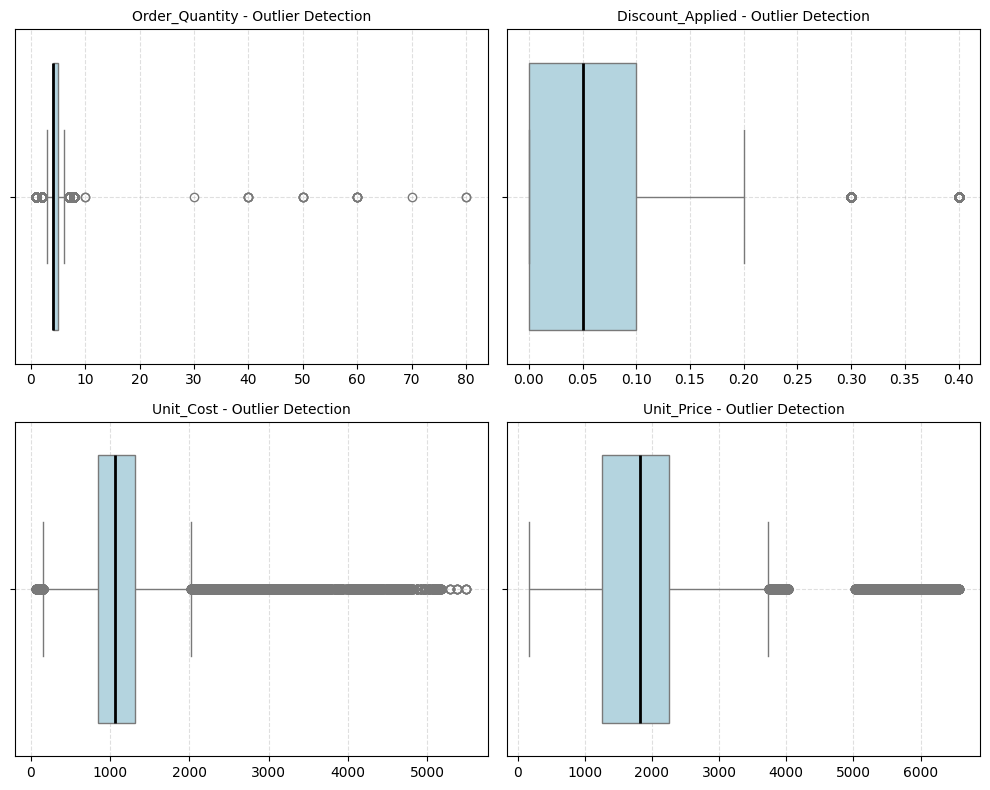

In [38]:
# Get numeric columns
num_cols = numeric_df.columns

# Grid size — adjust as you wish (2x2 gives the layout you showed)
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# Create figure and axes grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()  # flatten for easy looping

# Loop through numeric columns and plot
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightblue', medianprops={'color': 'black', 'linewidth': 2})
    axes[i].set_title(f'{col} - Outlier Detection', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].grid(True, linestyle='--', alpha=0.4)

# Remove unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Capping

In [39]:
for col in numeric_df:
    df[col] = np.where(df[col] < Lower_limit[col], Lower_limit[col],
              np.where(df[col] > Upper_limit[col], Upper_limit[col], df[col]))

After Capping the graphs

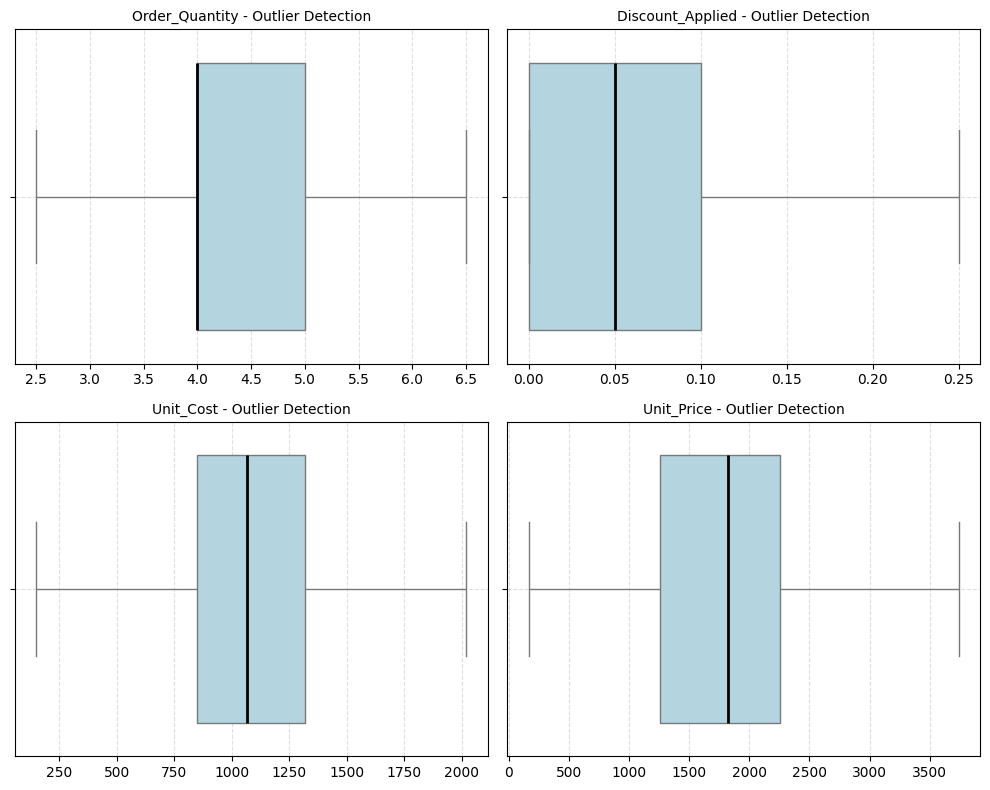

In [40]:
# Get numeric columns
num_cols = numeric_df.columns

# Grid size — adjust as you wish (2x2 gives the layout you showed)
n_cols = 2
n_rows = math.ceil(len(num_cols) / n_cols)

# Create figure and axes grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()  # flatten for easy looping

# Loop through numeric columns and plot
for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='lightblue', medianprops={'color': 'black', 'linewidth': 2})
    axes[i].set_title(f'{col} - Outlier Detection', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].grid(True, linestyle='--', alpha=0.4)

# Remove unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

. Business Logic Checks

In [41]:
# Delivery must happen after Shipping
condition1 = df[df['Delivery_Date'] < df['Ship_Date']]

# Shipping must happen after Order
condition2 = df[df['Ship_Date'] < df['Order_Date']]

# Order quantity must be positive
condition3 = df[df['Order_Quantity'] <= 0]

# Discount must be between 0 and 1
condition4 = df[(df['Discount_Applied'] < 0) | (df['Discount_Applied'] > 1)]

# Unit price should not be less than unit cost (unless loss allowed)
condition5 = df[df['Unit_Price'] < df['Unit_Cost']]


Display How Many Rows Violate Each Rule

In [42]:
print("Delivery before Shipping:", len(condition1))
print("Shipping before Order:", len(condition2))
print("Non-positive Order Quantity:", len(condition3))
print("Invalid Discount:", len(condition4))
print("Unit Price < Unit Cost:", len(condition5))


Delivery before Shipping: 103
Shipping before Order: 0
Non-positive Order Quantity: 0
Invalid Discount: 0
Unit Price < Unit Cost: 4594


Remove rows where delivery happened before shipping

In [43]:
df = df[df['Delivery_Date'] >= df['Ship_Date']]

Remove rows where Unit Price < Unit Cost

In [44]:
df = df[df['Unit_Price'] >= df['Unit_Cost']]

Reset index after removals

In [45]:
df = df.reset_index(drop=True)

In [46]:

df.to_csv("cleaned_order_data.csv")

In [47]:
df.shape

(27163, 16)

EDA

✅ 1. Feature Engineering

We create new financial and time-based metrics.

In [48]:
# Financial Metrics

df['Total_Price'] = df['Order_Quantity'] * df['Unit_Price']
df['Total_Cost'] = df['Order_Quantity'] * df['Unit_Cost']
df['Revenue'] = df['Total_Price'] * (1 - df['Discount_Applied'])
df['Profit'] = df['Revenue'] - df['Total_Cost']
df['Profit_Margin'] = (df['Profit'] / df['Revenue']) * 100


# Time Based Metrics
df['Order_Processing_Time'] = (df['Ship_Date'] - df['Order_Date']).dt.days
df['Shipping_Time'] = (df['Delivery_Date'] - df['Ship_Date']).dt.days
df['Total_Delivery_Time'] = (df['Delivery_Date'] - df['Order_Date']).dt.days
df['Holding_Time'] = (df['Ship_Date'] - df['Procured_Date']).dt.days

# Filter out invalid calculations (e.g., negative days due to data errors)
df = df[df['Total_Delivery_Time'] >= 0]



In [49]:
num_cols = ['Order_Quantity', 'Discount_Applied', 'Unit_Cost', 'Unit_Price', 
            'Total_Price', 'Total_Cost', 'Revenue', 'Profit']

numeric_df = df[num_cols]   # <-- This makes it a DataFrame, not a list

In [50]:
cat_cols = ['Sales_Channel', 'Warehouse_Code', 'Sales_Team_Id', 'Customer_Id', 'Store_Id', 'Product_Id']

category_df = df[cat_cols]


🟥 2. Univariate Analysis

Numerical Summary

In [51]:
numeric_df.describe()

,Order_Quantity,Discount_Applied,Unit_Cost,Unit_Price,Total_Price,Total_Cost,Revenue,Profit
count,27163.000000,27163.000000,27163.000000,27163.000000,27163.00000,27163.000000,27163.000000,27163.000000
mean,4.296028,0.063956,1053.664833,2051.828443,8843.78257,4527.187668,8273.955545,3746.767877
std,1.278164,0.071705,486.688805,948.967650,5073.62024,2570.851754,4788.708698,3235.932890
min,2.500000,0.000000,150.560000,167.500000,418.75000,376.400000,326.625000,-2935.270000
25%,4.000000,0.000000,754.585000,1802.300000,5192.50000,2663.250000,4687.320000,1511.520000
50%,4.000000,0.050000,1065.300000,1822.400000,7289.60000,4261.200000,7289.600000,3028.400000
75%,5.000000,0.100000,1102.020000,2485.700000,11845.60000,6121.920000,10897.952000,5185.800000
max,6.500000,0.250000,2019.040000,3738.600000,24300.90000,13123.760000,24300.900000,17376.450000


Histogram for Numerical Columns

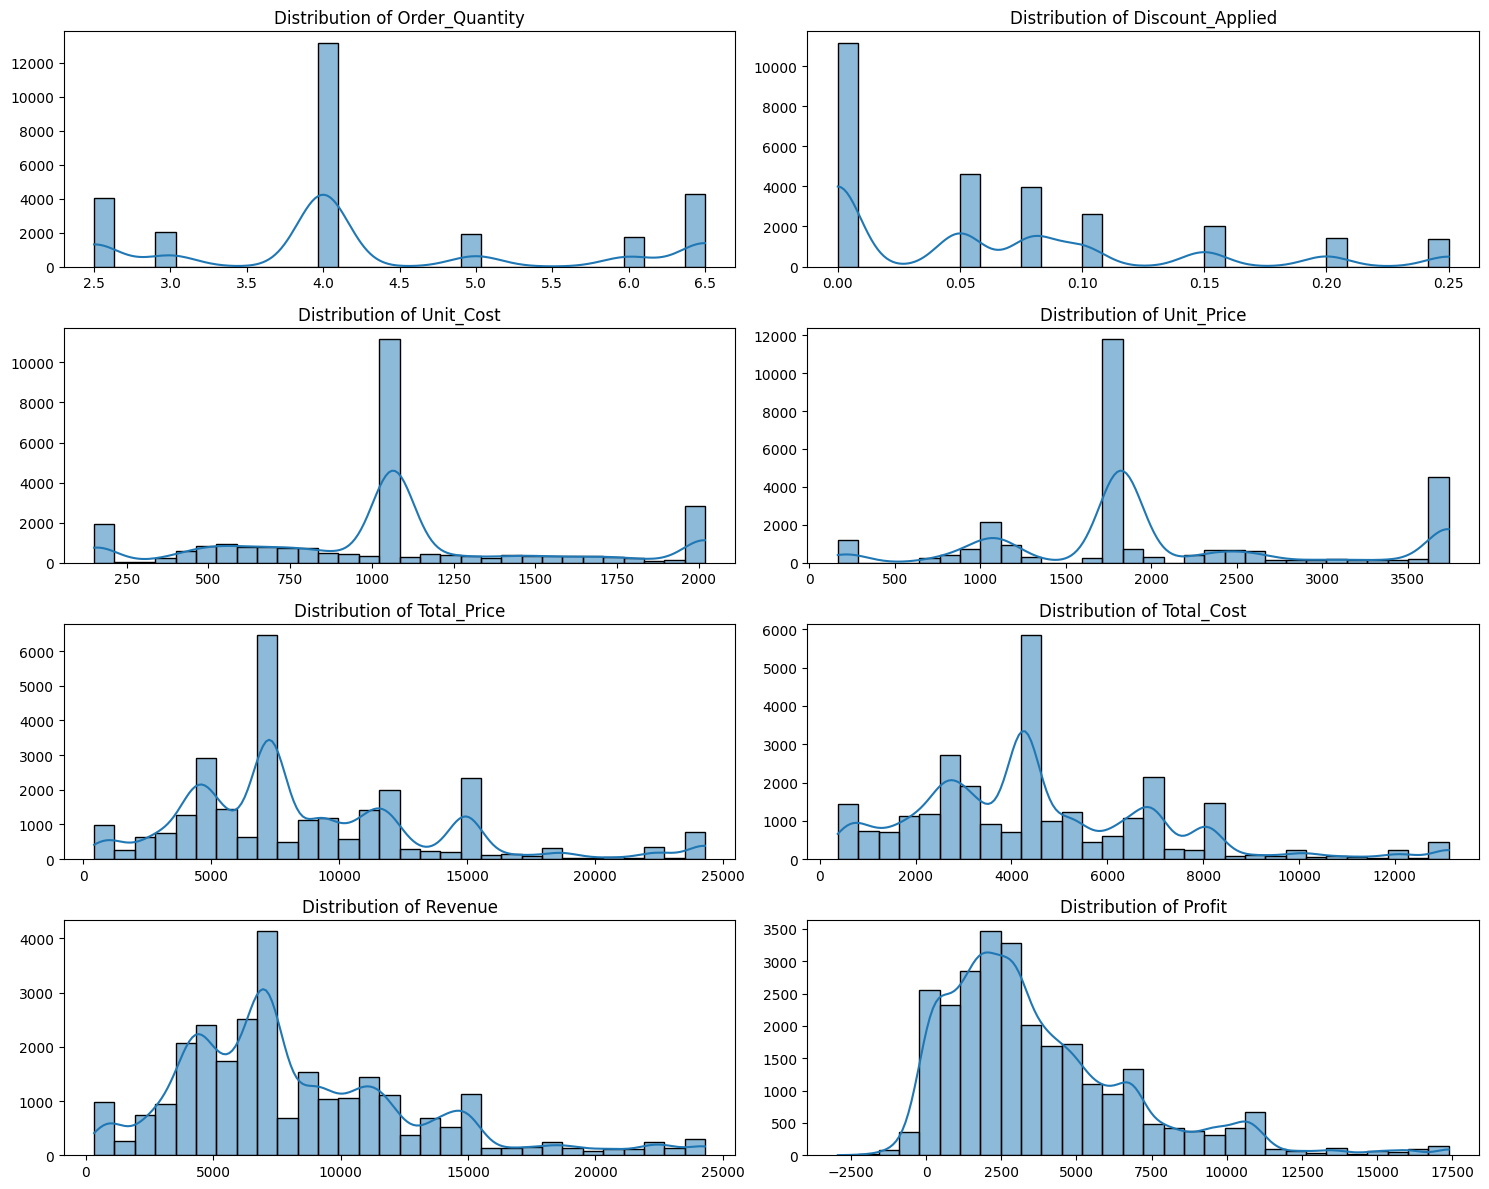

In [52]:
# Assume numeric_df is a DataFrame containing only numeric columns
numeric_cols = numeric_df.columns
num_cols = len(numeric_cols)

# Define grid size (for example, 3 columns per row)
ncols = 2
nrows = (num_cols // ncols) + int(num_cols % ncols != 0)

plt.figure(figsize=(15, nrows * 3))  # Adjust figure size

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(numeric_df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()


Categorical Analysis

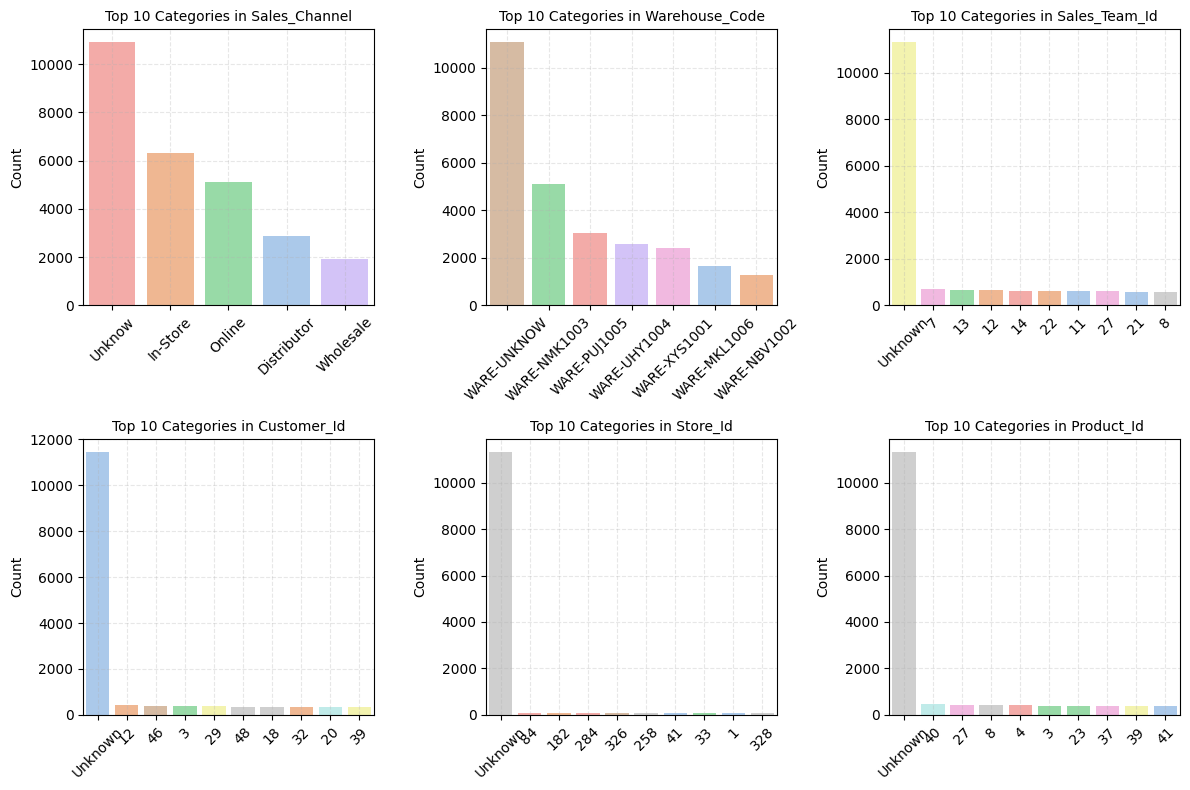

In [53]:
# Get categorical columns
cat_cols = category_df.columns

# Grid size — adjust as needed
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

# Create figure and axes grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()  # flatten for easy looping

# Loop through categorical columns and plot
for i, col in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=col,
        hue=col,  # assign hue to x
        legend=False,  # hide legend
        ax=axes[i],
        order=df[col].value_counts().index[:10],
        palette='pastel'
    )
    axes[i].set_title(f'Top 10 Categories in {col}', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, linestyle='--', alpha=0.3)

# Remove unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

🤝 3. Bivariate Analysis

Scatter Plots (Numerical vs Numerical)

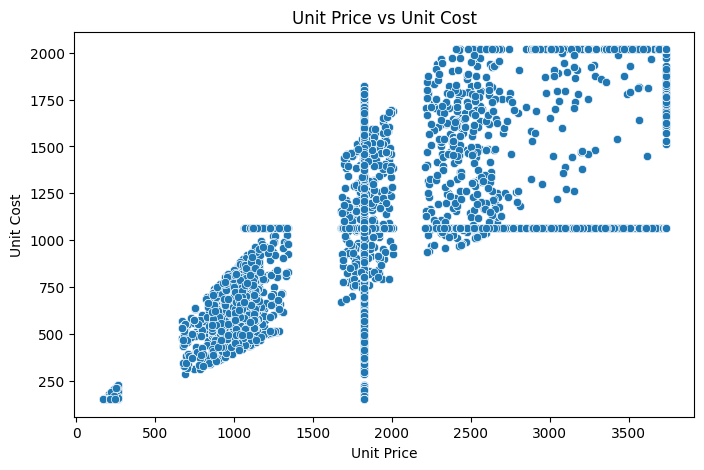

In [54]:
# Unit Price VS Unit Cost
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Unit_Price', y='Unit_Cost')
plt.title("Unit Price vs Unit Cost")
plt.xlabel("Unit Price")
plt.ylabel("Unit Cost")
plt.show()



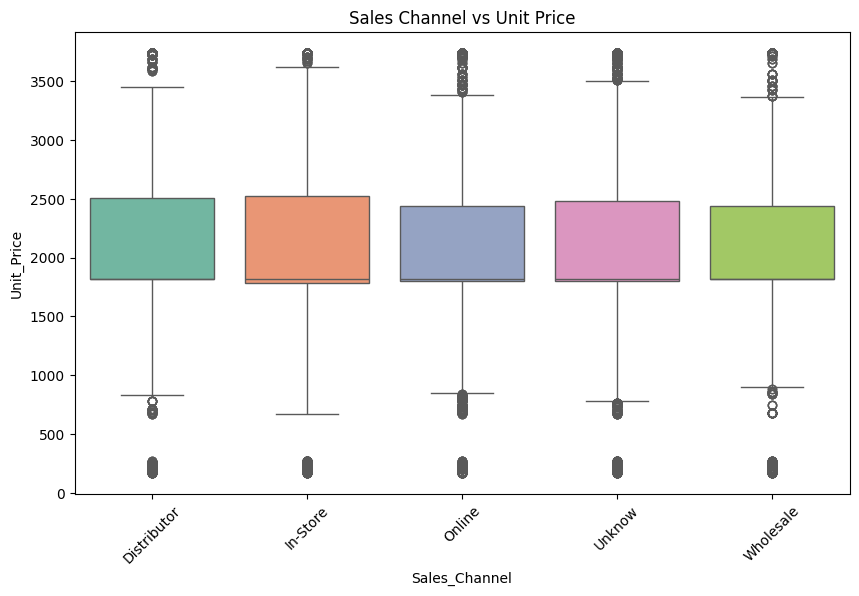

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Sales_Channel', y='Unit_Price',hue='Sales_Channel', palette='Set2')
plt.xticks(rotation=45)
plt.title('Sales Channel vs Unit Price')
plt.show()

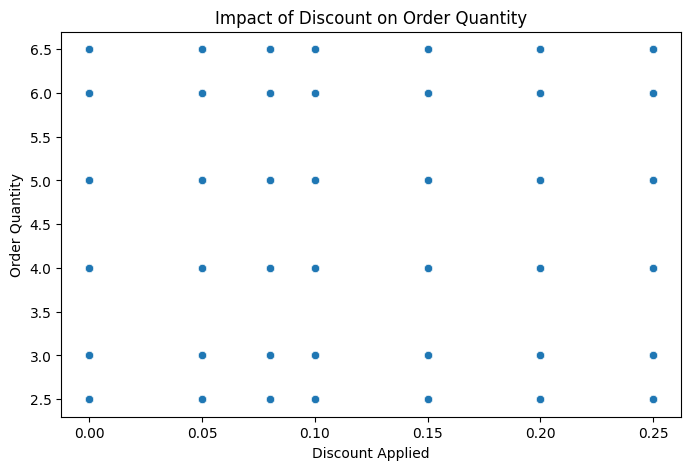

In [56]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount_Applied', y='Order_Quantity')
plt.title("Impact of Discount on Order Quantity")
plt.xlabel("Discount Applied")
plt.ylabel("Order Quantity")
plt.show()


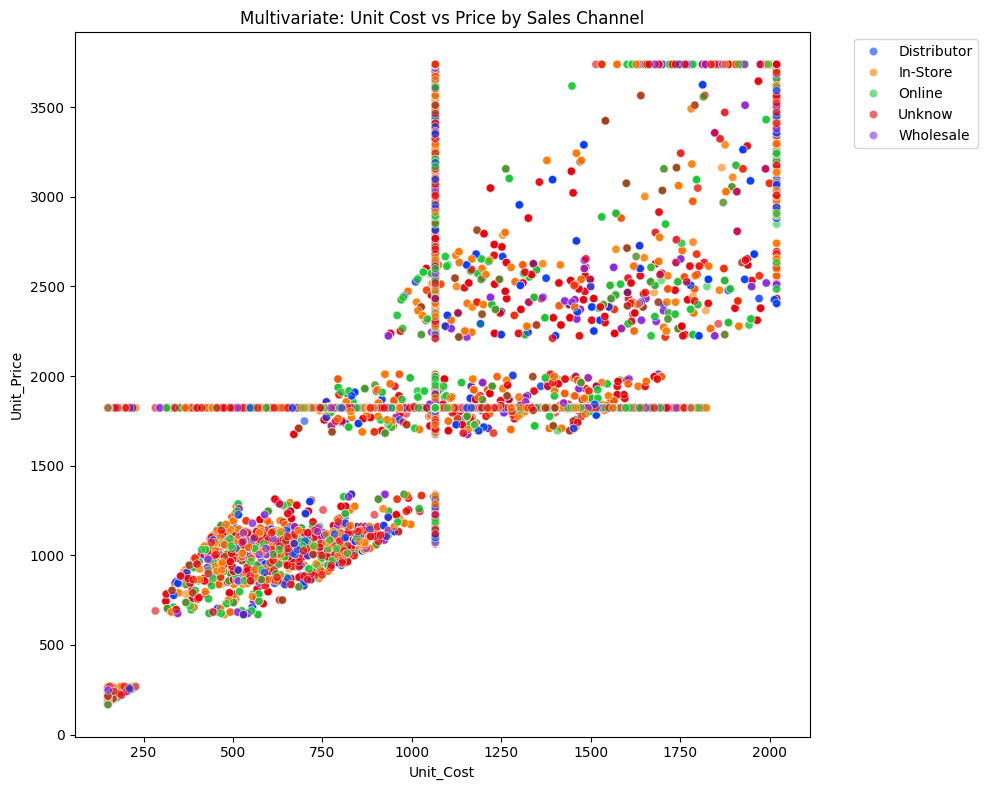

In [57]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='Unit_Cost', y='Unit_Price', hue='Sales_Channel', 
                alpha=0.6, palette='bright')
plt.title('Multivariate: Unit Cost vs Price by Sales Channel')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

Correlation Heatmap


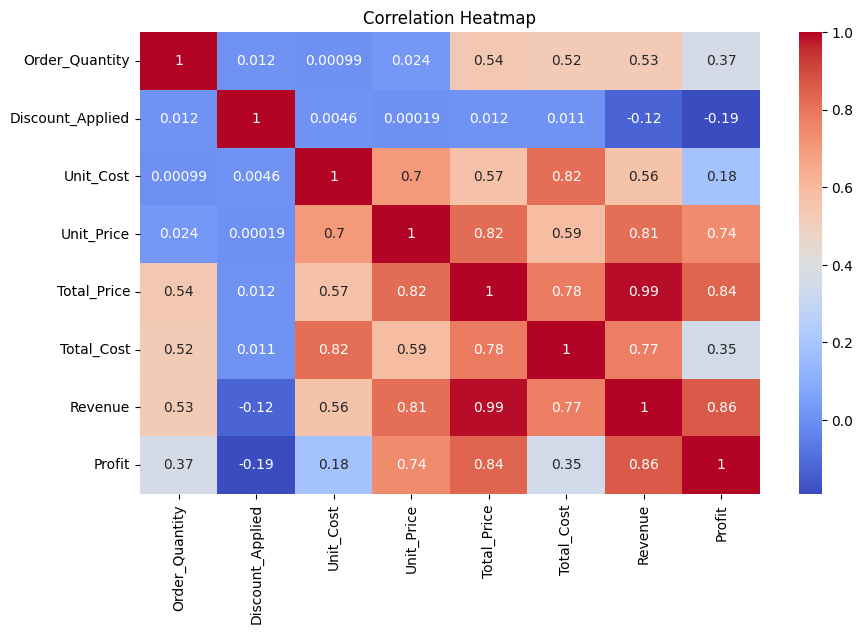

In [58]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Part 1: Inventory & Procurement
1. The "Cost of Dust" (Holding Time vs. Profit Margin)
We want to see if items held longer make less money. We will categorize Holding_Time into "bins" (e.g., 0-30 days, 30-60 days) to see the trend.

In [59]:
# Create bins for Holding Time (e.g., Short, Medium, Long, Excess)
bins = [0, 30, 60, 90, 999]
labels = ['0-30 Days', '30-60 Days', '60-90 Days', '90+ Days']
df['Holding_Category'] = pd.cut(df['Holding_Time'], bins=bins, labels=labels)

# Group by category to see average Profit Margin
holding_analysis = (
    df.groupby('Holding_Category', observed=True)['Profit_Margin'].mean().reset_index())


print(holding_analysis)

  Holding_Category  Profit_Margin
0       30-60 Days      41.388881
1       60-90 Days      40.215529
2         90+ Days      40.678036


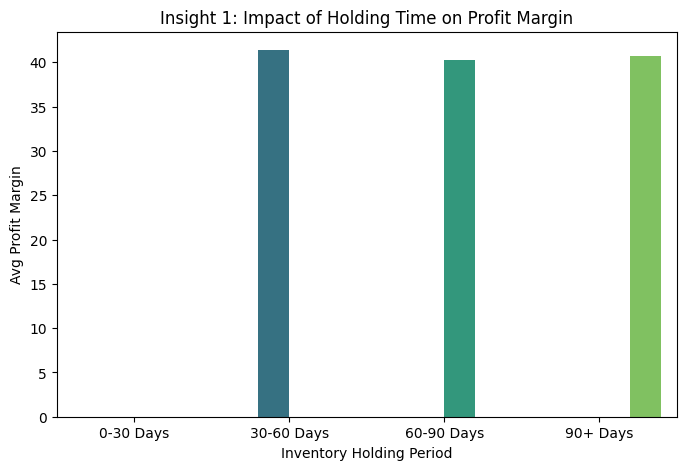

In [60]:
# --- Plot 1: Holding Time vs Profit Margin ---
plt.figure(figsize=(8, 5))
sns.barplot(data=holding_analysis,x='Holding_Category',y='Profit_Margin',hue='Holding_Category',palette='viridis',legend=False)
plt.title('Insight 1: Impact of Holding Time on Profit Margin')
plt.ylabel('Avg Profit Margin')
plt.xlabel('Inventory Holding Period')
plt.show()

ANOVA Test (For Insight 1: Holding Time)
Goal: Prove that Profit_Margin is different across the multiple categories (30-60 Days, 60-90 Days, 90+ Days).

When to use: When comparing means of more than two groups.

In [61]:
# 1. Prepare the groups based on your 'Holding_Category'
group_1 = df[df['Holding_Category'] == '30-60 Days']['Profit_Margin']
group_2 = df[df['Holding_Category'] == '60-90 Days']['Profit_Margin']
group_3 = df[df['Holding_Category'] == '90+ Days']['Profit_Margin']

# 2. Perform One-Way ANOVA
f_stat, p_val = stats.f_oneway(group_1, group_2, group_3)

print(f"P-Value: {p_val:.5f}")

if p_val < 0.05:
    print("✅ Confirmed: How long we hold inventory definitely affects our profit.")
else:
    print("❌ No Proof: Holding time doesn't statistically change profit.")

P-Value: 0.76254
❌ No Proof: Holding time doesn't statistically change profit.


Business Summary: This table shows the "decay rate" of your inventory value. If "90+ Days" has a significantly lower margin than "0-30 Days," it proves that holding old stock is actively hurting profitability.

2. Just-In-Time (JIT) Efficiency Gap
We compare how much stock we procured in a month vs. how much we actually sold (ordered).

In [62]:
# Resample Procurement Data by Month
procurement_monthly = df.set_index('Procured_Date').resample('M')['Order_Quantity'].sum()

# Resample Sales Order Data by Month
sales_monthly = df.set_index('Order_Date').resample('M')['Order_Quantity'].sum()

# Combine into one DataFrame for comparison
jit_df = pd.DataFrame({
    'Units_Procured': procurement_monthly,
    'Units_Sold': sales_monthly
}).fillna(0)

# Calculate the Gap
jit_df['Overstock_Gap'] = jit_df['Units_Procured'] - jit_df['Units_Sold']

print(jit_df.head())

            Units_Procured  Units_Sold  Overstock_Gap
2018-01-31            40.0         0.0           40.0
2018-02-28          1725.0         0.0         1725.0
2018-03-31          1812.5         0.0         1812.5
2018-04-30         12474.0         0.0        12474.0
2018-05-31          2064.5       116.0         1948.5


C:\Users\kotha\AppData\Local\Temp\ipykernel_10716\3747962431.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  procurement_monthly = df.set_index('Procured_Date').resample('M')['Order_Quantity'].sum()
C:\Users\kotha\AppData\Local\Temp\ipykernel_10716\3747962431.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_monthly = df.set_index('Order_Date').resample('M')['Order_Quantity'].sum()


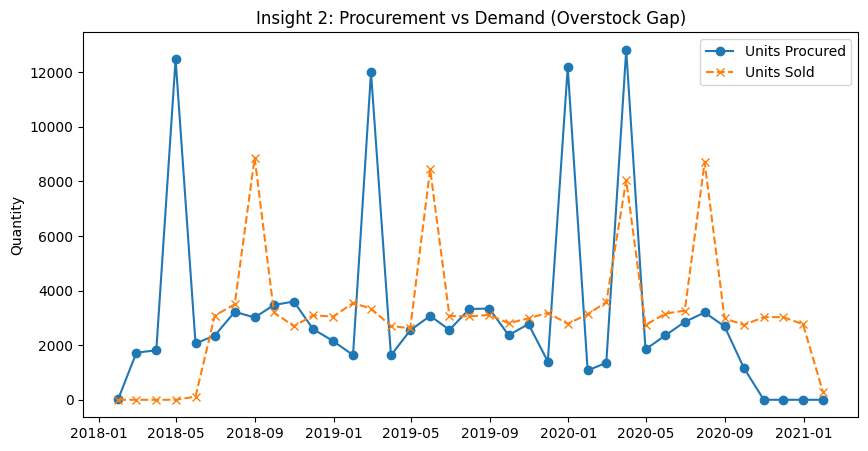

In [63]:
# --- Plot 2: JIT Efficiency Gap ---
plt.figure(figsize=(10, 5))
plt.plot(jit_df.index, jit_df['Units_Procured'], label='Units Procured', marker='o')
plt.plot(jit_df.index, jit_df['Units_Sold'], label='Units Sold', marker='x', linestyle='--')
plt.title('Insight 2: Procurement vs Demand (Overstock Gap)')
plt.ylabel('Quantity')
plt.legend()
plt.show()

Business Summary: Positive values in Overstock_Gap mean you bought more than you sold (Stockpiling). Negative values mean you sold from existing stock. Large positive spikes indicate poor cash flow management (buying too early).

Part 2: Warehouse & Logistics
3. The "Warehouse Bottleneck" (Processing vs. Shipping)
We split the delivery time to see if the delay is inside the warehouse or on the truck.

In [64]:
# Group by Warehouse and calculate average times
warehouse_efficiency = df.groupby('Warehouse_Code',observed=True).agg({
    'Order_Processing_Time': 'mean',
    'Shipping_Time': 'mean',
    'Order_Number': 'count'  # To see volume
}).reset_index()

# Sort by slowest processing time
warehouse_efficiency = warehouse_efficiency.sort_values(by='Order_Processing_Time', ascending=False)

print(warehouse_efficiency)

  Warehouse_Code  Order_Processing_Time  Shipping_Time  Order_Number
2   WARE-NMK1003               9.603995       7.259890          5106
4   WARE-UHY1004               9.453462       7.547692          2600
5    WARE-UNKNOW               9.354833       7.373171         11070
6   WARE-XYS1001               9.288023       7.424782          2413
3   WARE-PUJ1005               9.284585       7.334980          3036
1   WARE-NBV1002               9.276378       7.253543          1270
0   WARE-MKL1006               9.196043       7.410671          1668


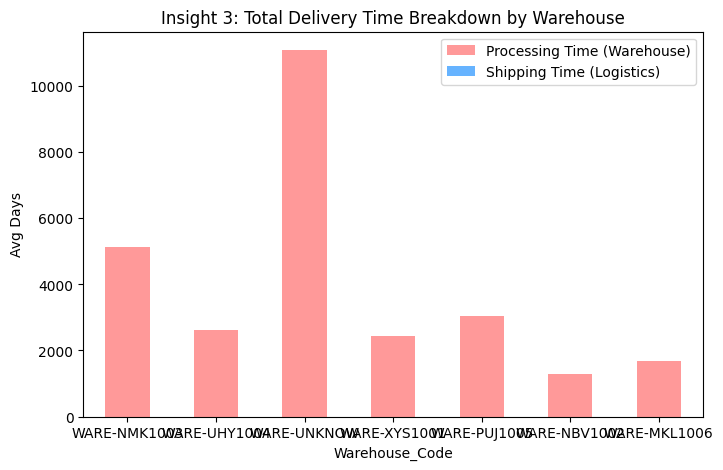

In [65]:
# --- Plot 3: Warehouse Bottleneck ---
# Note: Ensure 'wh_efficiency' is calculated as shown in previous steps
warehouse_efficiency.set_index('Warehouse_Code').plot(
    kind='bar', stacked=True, figsize=(8, 5), color=['#ff9999','#66b3ff']
)
plt.title('Insight 3: Total Delivery Time Breakdown by Warehouse')
plt.ylabel('Avg Days')
plt.legend(['Processing Time (Warehouse)', 'Shipping Time (Logistics)'])
plt.xticks(rotation=0)
plt.show()

1. The "T-Test" (For Insight 3: Warehouse Bottleneck)
Goal: Prove that Warehouse A is actually faster than Warehouse B, and it's not just random luck.

When to use: When comparing the means of two groups.

In [66]:

# 1. Filter data + drop NaN values
wh_a_times = (
    df.loc[df['Warehouse_Code'] == 'WH-A', 'Order_Processing_Time']
      .dropna()
)

wh_b_times = (
    df.loc[df['Warehouse_Code'] == 'WH-B', 'Order_Processing_Time']
      .dropna()
)

# 2. Check minimum sample size before t-test
if len(wh_a_times) >= 2 and len(wh_b_times) >= 2:

    t_stat, p_val = stats.ttest_ind(
        wh_a_times,
        wh_b_times,
        equal_var=False   # Welch's t-test (best practice)
    )

    print(f"P-Value: {p_val:.5f}")

    if p_val < 0.05:
        print("✅ Result is Statistically Significant: Warehouse A is truly different from Warehouse B.")
    else:
        print("❌ Result is NOT Significant: The difference might be due to random chance.")

else:
    print("⚠️ T-test NOT performed.")
    print(f"WH-A sample size: {len(wh_a_times)}")
    print(f"WH-B sample size: {len(wh_b_times)}")
    print("Reason: Each group must have at least 2 observations.")


⚠️ T-test NOT performed.
WH-A sample size: 0
WH-B sample size: 0
Reason: Each group must have at least 2 observations.


Business Summary: This identifies the specific facility slowing down the supply chain. If Warehouse A takes 4 days to process but Warehouse B takes 1 day, Warehouse A is the bottleneck requiring operational audit.

4. Performance Variance by Warehouse
We look at the consistency of each warehouse.

In [67]:
# Calculate Standard Deviation to see consistency (volatility)

warehouse_consistency = (df.groupby('Warehouse_Code', observed=True)['Order_Processing_Time'].std().reset_index())
warehouse_consistency.columns = ['Warehouse_Code', 'Processing_Time_Std_Dev']

# Merge with average time for context
warehouse_variance = pd.merge(warehouse_efficiency, warehouse_consistency, on='Warehouse_Code')

print(warehouse_variance)

  Warehouse_Code  Order_Processing_Time  Shipping_Time  Order_Number  \
0   WARE-NMK1003               9.603995       7.259890          5106   
1   WARE-UHY1004               9.453462       7.547692          2600   
2    WARE-UNKNOW               9.354833       7.373171         11070   
3   WARE-XYS1001               9.288023       7.424782          2413   
4   WARE-PUJ1005               9.284585       7.334980          3036   
5   WARE-NBV1002               9.276378       7.253543          1270   
6   WARE-MKL1006               9.196043       7.410671          1668   

   Processing_Time_Std_Dev  
0                 3.489098  
1                 3.181829  
2                 2.938436  
3                 3.000748  
4                 2.892820  
5                 3.037718  
6                 2.313583  


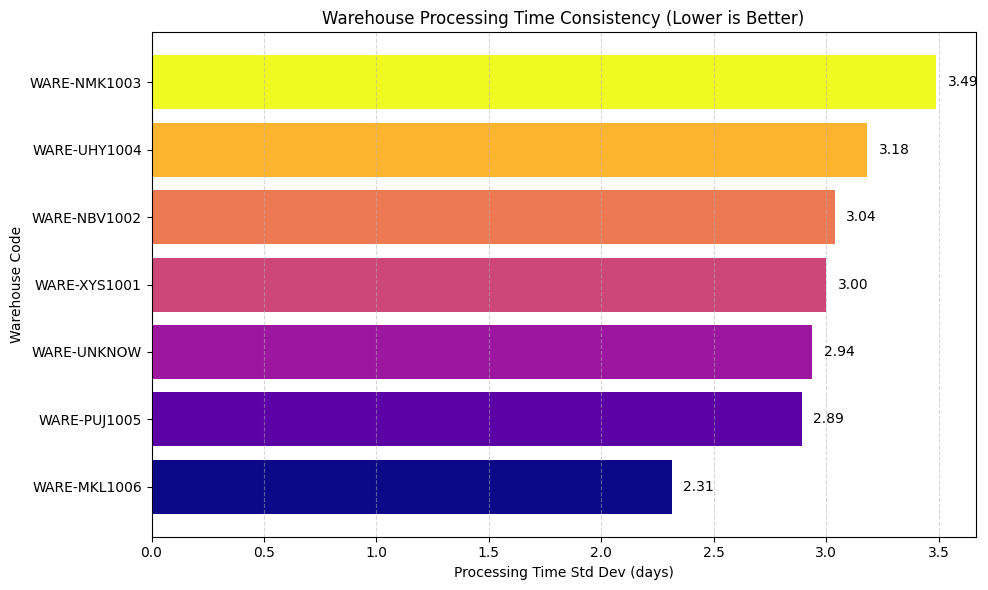

In [68]:


# Sort by consistency (low std dev = better)
warehouse_variance_sorted = warehouse_variance.sort_values(
    by='Processing_Time_Std_Dev', ascending=True
)

plt.figure(figsize=(10,6))

# Create colors using colormap
colors = plt.cm.plasma(
    np.linspace(0, 1, len(warehouse_variance_sorted))
)

bars = plt.barh(
    warehouse_variance_sorted['Warehouse_Code'],
    warehouse_variance_sorted['Processing_Time_Std_Dev'],
    color=colors
)

plt.xlabel('Processing Time Std Dev (days)')
plt.ylabel('Warehouse Code')
plt.title('Warehouse Processing Time Consistency (Lower is Better)')

# Value labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center'
    )

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



Business Summary: A high Standard Deviation (Std_Dev) means the warehouse is unpredictable—sometimes fast, sometimes very slow. Supply chains hate unpredictability more than slowness.

Part 3: Sales & Profitability
5. The "Discount Trap" (Sales Team Analysis)
Identify sales teams that sacrifice profit to hit volume targets.

In [69]:
# Aggregating metrics by Sales Team

team_perf = (
    df.groupby('Sales_Team_Id', observed=True)
      .agg({
          'Revenue': 'sum',
          'Profit_Margin': 'mean',
          'Discount_Applied': 'mean',
          'Order_Processing_Time': 'mean'
      })
      .reset_index()
)

# Sort by Discount Applied (Highest to Lowest)
team_performance = team_perf.sort_values(by='Discount_Applied', ascending=False)

print(team_performance.head())

   Sales_Team_Id       Revenue  Profit_Margin  Discount_Applied  \
0              1  4.985348e+06      41.809713          0.077307   
27            28  4.187622e+06      39.537062          0.072239   
23            24  4.938864e+06      40.828409          0.071638   
12            13  5.238810e+06      43.230322          0.070857   
11            12  5.475203e+06      41.391373          0.070288   

    Order_Processing_Time  
0                9.615780  
27               9.269725  
23               9.735192  
12               9.183459  
11               8.921212  


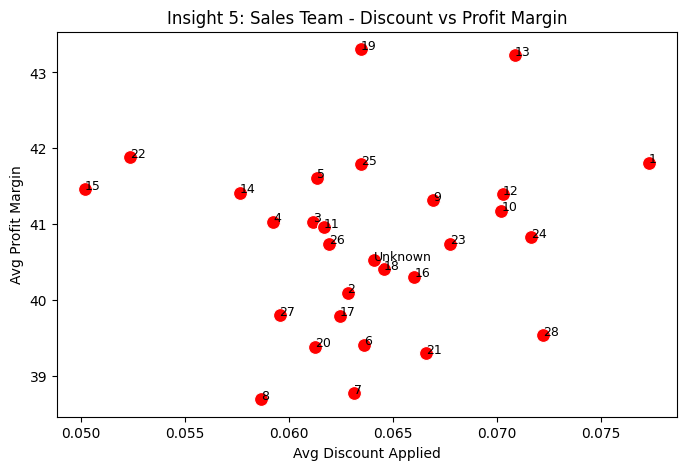

In [70]:
# --- Plot 5: The Discount Trap ---
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Discount_Applied', y='Profit_Margin', data=team_perf, s=100, color='red')
# Label points
for i in range(team_perf.shape[0]):
    plt.text(
        team_perf.Discount_Applied[i], 
        team_perf.Profit_Margin[i], 
        team_perf.Sales_Team_Id[i], 
        fontsize=9
    )
plt.title('Insight 5: Sales Team - Discount vs Profit Margin')
plt.xlabel('Avg Discount Applied')
plt.ylabel('Avg Profit Margin')
plt.show()

 Pearson Correlation (For Insight 5: The Discount Trap)
Goal: Prove that increasing Discount_Applied directly lowers Profit_Margin.

When to use: When checking the relationship between two numbers.

In [71]:
# Calculate Correlation
corr_coef, p_val = stats.pearsonr(df['Discount_Applied'], df['Profit_Margin'])

print(f"Correlation: {corr_coef:.2f}")
print(f"P-Value: {p_val:.5f}")

if p_val < 0.05 and corr_coef < 0:
    print("✅ Confirmed: Higher discounts statistically destroy profit margins.")

Correlation: -0.24
P-Value: 0.00000
✅ Confirmed: Higher discounts statistically destroy profit margins.


Business Summary: If the top rows (high discount teams) have low Profit Margins or low Total Profit, these teams are "buying sales" rather than selling value. This is a training issue.

6. Channel Profitability
Compare which sales channel is actually efficient.

In [72]:
channel_analysis = (
    df.groupby('Sales_Channel', observed=True)
      .agg({
          'Revenue': 'sum',
          'Profit_Margin': 'mean',
          'Order_Processing_Time': 'mean'
      })
      .reset_index()
)


print(channel_analysis)

  Sales_Channel       Revenue  Profit_Margin  Order_Processing_Time
0   Distributor  2.430003e+07      40.673045               9.405085
1      In-Store  5.250439e+07      40.370156               9.429812
2        Online  4.175420e+07      40.612195               9.368298
3        Unknow  9.065194e+07      41.028071               9.350826
4     Wholesale  1.553490e+07      39.728902               9.430052


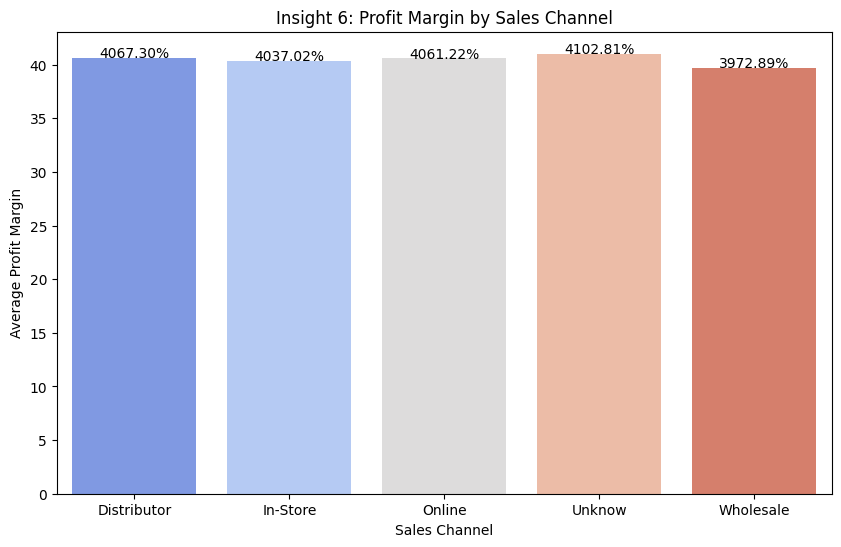

In [73]:
# --- Plot 6: Channel Profitability ---
plt.figure(figsize=(10, 6))
# Using a 'coolwarm' palette to show hot/cold profit zones
sns.barplot(
    data=channel_analysis,
    x='Sales_Channel',
    y='Profit_Margin',
    hue='Sales_Channel',
    palette='coolwarm',
    legend=False
)


plt.title('Insight 6: Profit Margin by Sales Channel')
plt.ylabel('Average Profit Margin')
plt.xlabel('Sales Channel')
# Add percentage labels on top of bars
for index, row in channel_analysis.iterrows():
    plt.text(index, row.Profit_Margin, f'{row.Profit_Margin:.2%}', color='black', ha="center")
plt.show()

Business Summary: This reveals the quality of revenue. Usually, B2B (Distributors) has high volume but lower margin, while B2C (Online) has lower volume but higher margin. This helps decide where to allocate marketing budget.

7. Negative Profit Identification (Loss Leaders)
Find the products that are bleeding money.

In [74]:
# Filter only rows where Profit is negative
loss_makers = df[df['Profit'] < 0]

# Group by Product to see the biggest losers
product_losses = (
    loss_makers.groupby('Product_Id', observed=True)
               .agg({
                   'Revenue': 'sum',
                   'Profit': 'sum', # Total money lost
                   'Profit_Margin': 'mean',
                   'Order_Quantity': 'sum' # How many units sold at a loss
               })
               .reset_index()
)


# Sort by biggest loss
product_losses = product_losses.sort_values(by='Profit', ascending=True) # Ascending because numbers are negative

print(product_losses.head(10))

   Product_Id       Revenue       Profit  Profit_Margin  Order_Quantity
47    Unknown  1.810685e+06 -144538.3320      -8.257266          1705.5
20         21  1.196662e+05  -19138.5160     -15.516680           102.0
10         11  1.512244e+05  -14880.0300     -10.900559           137.5
16         17  1.126735e+05  -13172.8820     -12.548614            93.0
35         36  8.908477e+04  -12597.8205     -12.943038            95.5
4           5  9.405299e+04  -11942.3080     -12.491042            85.0
2           3  9.948696e+04   -9354.9800      -9.227196            68.0
30         31  1.036227e+05   -7539.3725      -7.157418            89.0
27         28  8.655328e+04   -7516.8000      -8.959511            77.5
38         39  1.061448e+05   -7481.3950      -6.182152            91.0


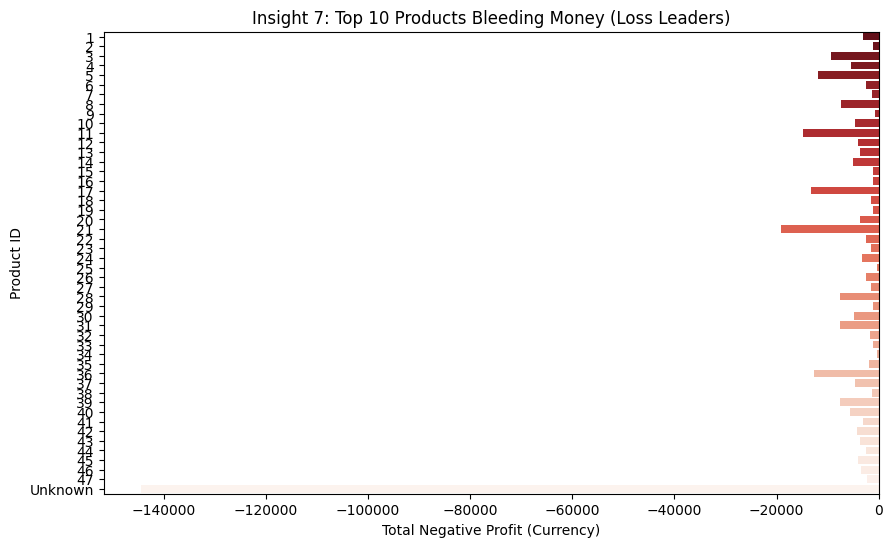

In [75]:
# --- Plot 7: Top 10 Money-Losing Products ---
plt.figure(figsize=(10, 6))
# Horizontal bar chart is better for reading Product IDs
sns.barplot(
    data=product_losses,
    x='Profit',
    y='Product_Id',
    hue='Product_Id',
    palette='Reds_r',
    legend=False
)
plt.title('Insight 7: Top 10 Products Bleeding Money (Loss Leaders)')
plt.xlabel('Total Negative Profit (Currency)')
plt.ylabel('Product ID')
plt.show()

Business Summary: These are your "Cash Burners." These top 10 products are actively reducing the company's bottom line. The recommendation is usually to stop selling them, raise prices, or lower supplier costs.

In [76]:
df.to_csv("cleaned_order_data.csv")

In [77]:
df.columns

Index(['Order_Number', 'Sales_Channel', 'Warehouse_Code', 'Procured_Date',
       'Order_Date', 'Ship_Date', 'Delivery_Date', 'Currency_Code',
       'Sales_Team_Id', 'Customer_Id', 'Store_Id', 'Product_Id',
       'Order_Quantity', 'Discount_Applied', 'Unit_Cost', 'Unit_Price',
       'Total_Price', 'Total_Cost', 'Revenue', 'Profit', 'Profit_Margin',
       'Order_Processing_Time', 'Shipping_Time', 'Total_Delivery_Time',
       'Holding_Time', 'Holding_Category'],
      dtype='object')